In [334]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [335]:
df=pd.read_csv("final_ds.csv")
df.head()

,cycle_phase_Luteal,cycle_phase_Menstrual,pms_symptoms_Yes,ovulation_result_Positive,user_id,cycle_number,start_date,cycle_length_days,prev_cycle_length,flow_level,...,diet_quality,exercise_frequency,sleep_hours,caffeine_intake,water_intake_liters,alcohol_consumption,smoking_status,birth_control_use,pcos_diagnosed,stress_score_baseline
0,0.0,0.0,0.0,0.0,U00001,2,3/17/2024,33,33.0,0.0,...,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
1,0.0,0.0,0.0,0.0,U00001,3,4/19/2024,34,33.0,2.0,...,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
2,1.0,0.0,0.0,0.0,U00001,4,5/23/2024,31,34.0,0.0,...,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
3,1.0,0.0,0.0,0.0,U00001,5,6/23/2024,31,31.0,1.0,...,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1
4,1.0,0.0,0.0,0.0,U00001,6,7/24/2024,37,31.0,1.0,...,2.0,2.0,5.4,1.5,2.0,1.0,0,1,1,4.1


In [336]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [337]:
df.columns

Index(['cycle_phase_Luteal', 'cycle_phase_Menstrual', 'pms_symptoms_Yes',
       'ovulation_result_Positive', 'user_id', 'cycle_number', 'start_date',
       'cycle_length_days', 'prev_cycle_length', 'flow_level', 'pain_level',
       'mood_score', 'stress_score_cycle', 'sleep_hours_cycle', 'energy_level',
       'concentration_score', 'work_hours_lost', 'estrogen_pgml',
       'progesterone_ngml', 'overall_health_score', 'log_consistency_score',
       'prepared_before_period', 'state', 'age', 'bmi', 'diet_quality',
       'exercise_frequency', 'sleep_hours', 'caffeine_intake',
       'water_intake_liters', 'alcohol_consumption', 'smoking_status',
       'birth_control_use', 'pcos_diagnosed', 'stress_score_baseline'],
      dtype='object')

In [338]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge,SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,KFold,cross_val_score

In [339]:
X=df.drop(["pain_level","start_date","user_id","state"],axis=1)
X.columns

Index(['cycle_phase_Luteal', 'cycle_phase_Menstrual', 'pms_symptoms_Yes',
       'ovulation_result_Positive', 'cycle_number', 'cycle_length_days',
       'prev_cycle_length', 'flow_level', 'mood_score', 'stress_score_cycle',
       'sleep_hours_cycle', 'energy_level', 'concentration_score',
       'work_hours_lost', 'estrogen_pgml', 'progesterone_ngml',
       'overall_health_score', 'log_consistency_score',
       'prepared_before_period', 'age', 'bmi', 'diet_quality',
       'exercise_frequency', 'sleep_hours', 'caffeine_intake',
       'water_intake_liters', 'alcohol_consumption', 'smoking_status',
       'birth_control_use', 'pcos_diagnosed', 'stress_score_baseline'],
      dtype='object')

In [340]:
y=df["pain_level"]

In [341]:
y.head()

,pain_level
0,2
1,8
2,3
3,3
4,6


In [342]:
X.drop(["cycle_number","prev_cycle_length"],axis=1,inplace=True)

In [343]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [344]:
pipeline=Pipeline([
    ("scaler",StandardScaler()),
    ("model",LinearRegression())
])

In [345]:
X_train.shape

(9012, 29)

In [346]:
kf=KFold(n_splits=10,shuffle=True,random_state=42)

In [347]:
cv_scores=cross_val_score(
    pipeline,
    X_train,y_train,
    cv=kf,
    scoring="r2"
)

In [348]:
pipeline.fit(X_train, y_train)          # train on full train+val
test_accuracy = pipeline.score(X_test, y_test)

print("\n=== Final Test Set Evaluation ===")
print(f"Test Accuracy : {test_accuracy:.4f}")


=== Final Test Set Evaluation ===
Test Accuracy : 0.9361


In [349]:
print("=== K-Fold Cross Validation Results ===")
print(f"Fold Scores : {np.round(cv_scores, 4)}")
print(f"Mean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Dev       : {cv_scores.std():.4f}")


=== K-Fold Cross Validation Results ===
Fold Scores : [0.9362 0.9337 0.9379 0.9295 0.9391 0.9376 0.9375 0.9349 0.9414 0.9409]
Mean Accuracy : 0.9369
Std Dev       : 0.0034


In [350]:
def models(model,X_train,y_train,X_test,y_test,name,n):
    kf=KFold(n_splits=n,shuffle=True,random_state=42)

    pipeline=Pipeline([
    ("scaler",StandardScaler()),
    ("model",model)])

    cv_scores=cross_val_score(
    pipeline,
    X_train,y_train,
    cv=kf,
    scoring="r2")

    pipeline.fit(X_train,y_train)
    test_r2 = pipeline.score(X_test, y_test)

    print(f"\n=== Final Test Set Evaluation for {name} R2 Score===")
    print(f"Test Accuracy : {test_r2:.4f}")

    print(f"=== K-Fold Cross Validation Results for {name} R2 Score===")
    print(f"Fold Scores : {np.round(cv_scores, 4)}")
    print(f"Mean Accuracy : {cv_scores.mean():.4f}")
    print(f"Std Dev       : {cv_scores.std():.4f}")

    n_samples = X_test.shape[0]
    n_features = X_test.shape[1]

    adj_r2 = 1 - (1 - test_r2) * (n_samples - 1) / (n_samples - n_features - 1)
    print(f"Adjusted R2 Score for {name}: {adj_r2:.4f}")

In [351]:
Sgd=SGDRegressor(loss="squared_error",penalty=None,max_iter=500)
models(Sgd,X_train,y_train,X_test,y_test,"SGD",10)


=== Final Test Set Evaluation for SGD R2 Score===
Test Accuracy : 0.9349
=== K-Fold Cross Validation Results for SGD R2 Score===
Fold Scores : [0.936  0.9322 0.9376 0.93   0.9388 0.9373 0.9369 0.934  0.9408 0.9408]
Mean Accuracy : 0.9364
Std Dev       : 0.0033
Adjusted R2 Score for SGD: 0.9344


In [352]:
ridge=Ridge(alpha=0.95,solver="svd")
models(ridge,X_train,y_train,X_test,y_test,"Ridge",10)


=== Final Test Set Evaluation for Ridge R2 Score===
Test Accuracy : 0.9361
=== K-Fold Cross Validation Results for Ridge R2 Score===
Fold Scores : [0.9362 0.9337 0.9379 0.9295 0.9391 0.9376 0.9375 0.9349 0.9414 0.941 ]
Mean Accuracy : 0.9369
Std Dev       : 0.0034
Adjusted R2 Score for Ridge: 0.9356


In [353]:
lasso=Lasso(alpha=0.55,max_iter=50)
models(lasso,X_train,y_train,X_test,y_test,"Lasso",5)


=== Final Test Set Evaluation for Lasso R2 Score===
Test Accuracy : 0.8102
=== K-Fold Cross Validation Results for Lasso R2 Score===
Fold Scores : [0.8102 0.813  0.8119 0.8059 0.8135]
Mean Accuracy : 0.8109
Std Dev       : 0.0027
Adjusted R2 Score for Lasso: 0.8088


In [354]:
from sklearn.metrics import r2_score

In [355]:
def tune_lasso(X_train, y_train, X_test, y_test,
               alphas=None, n_splits=10):

    if alphas is None:
        alphas = [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3, 0.5, 1.0, 5.0, 10.0]

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    n_train, p = X_train.shape
    n_test     = X_test.shape[0]

    results = []

    for alpha in alphas:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=alpha, max_iter=100))
        ])

        cv_scores = cross_val_score(pipeline, X_train, y_train,
                                    cv=kf, scoring='r2')

        pipeline.fit(X_train, y_train)

        # ── Train metrics ─────────────────────────────────────
        y_pred_train   = pipeline.predict(X_train)
        train_r2       = r2_score(y_train, y_pred_train)
        train_adj_r2   = 1 - (1 - train_r2) * (n_train - 1) / (n_train - p - 1)

        # ── Test metrics ──────────────────────────────────────
        y_pred_test    = pipeline.predict(X_test)
        test_r2        = r2_score(y_test, y_pred_test)
        test_adj_r2    = 1 - (1 - test_r2) * (n_test - 1) / (n_test - p - 1)

        results.append({
            'alpha'       : alpha,
            'mean_cv_r2'  : cv_scores.mean(),
            'std_cv_r2'   : cv_scores.std(),
            'train_r2'    : train_r2,
            'train_adj_r2': train_adj_r2,
            'test_r2'     : test_r2,
            'test_adj_r2' : test_adj_r2
        })

    best = max(results, key=lambda x: x['mean_cv_r2'])

    # ── Print all results ─────────────────────────────────────
    print("=" * 100)
    print(f"{'Alpha':<10} {'CV R²':<10} {'CV Std':<10} {'Train R²':<12} {'Train AdjR²':<14} {'Test R²':<10} {'Test AdjR²':<12}")
    print("=" * 100)
    for r in results:
        marker = " ← best" if r['alpha'] == best['alpha'] else ""
        print(f"{r['alpha']:<10} "
              f"{r['mean_cv_r2']:<10.4f} "
              f"{r['std_cv_r2']:<10.4f} "
              f"{r['train_r2']:<12.4f} "
              f"{r['train_adj_r2']:<14.4f} "
              f"{r['test_r2']:<10.4f} "
              f"{r['test_adj_r2']:<12.4f}{marker}")

    print("=" * 100)
    print(f"\n Best Alpha        : {best['alpha']}")
    print(f" CV R²             : {best['mean_cv_r2']:.4f}")
    print(f" Train R²          : {best['train_r2']:.4f}")
    print(f" Train Adjusted R² : {best['train_adj_r2']:.4f}")
    print(f" Test R²           : {best['test_r2']:.4f}")
    print(f" Test Adjusted R²  : {best['test_adj_r2']:.4f}")

    # ── Refit best pipeline ───────────────────────────────────
    best_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=best['alpha'], max_iter=50))
    ])
    best_pipeline.fit(X_train, y_train)

    return best_pipeline, best['alpha']

best_model, best_alpha = tune_lasso(X_train, y_train, X_test, y_test)

best_model.named_steps["model"].coef_

coefs = best_model.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coefficient': coefs
})

Alpha      CV R²      CV Std     Train R²     Train AdjR²    Test R²    Test AdjR²  
0.0001     0.9369     0.0034     0.9374       0.9372         0.9361     0.9356      
0.001      0.9369     0.0033     0.9374       0.9372         0.9361     0.9356       ← best
0.01       0.9365     0.0034     0.9368       0.9366         0.9358     0.9353      
0.1        0.9163     0.0047     0.9165       0.9162         0.9167     0.9161      
0.2        0.8971     0.0048     0.8974       0.8970         0.8979     0.8971      
0.3        0.8750     0.0049     0.8753       0.8749         0.8756     0.8746      
0.5        0.8254     0.0052     0.8256       0.8251         0.8252     0.8239      
1.0        0.6490     0.0055     0.6494       0.6482         0.6476     0.6449      
5.0        -0.0010    0.0011     0.0000       -0.0032        -0.0004    -0.0080     
10.0       -0.0010    0.0011     0.0000       -0.0032        -0.0004    -0.0080     

 Best Alpha        : 0.001
 CV R²             : 0.9369
 T

In [356]:
coefs = best_model.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Coefficient': coefs
})
coef_df

,Feature,Coefficient
0,cycle_phase_Luteal,-0.002592
1,cycle_phase_Menstrual,0.003182
2,pms_symptoms_Yes,-0.006311
3,ovulation_result_Positive,0.007313
4,cycle_length_days,-0.001075
5,flow_level,0.285875
6,mood_score,-0.109978
7,stress_score_cycle,-0.521281
8,sleep_hours_cycle,0.167197
9,energy_level,-0.145215


In [357]:
# 1. Check if scaler was fit on full data before splitting
#    (common mistake)
# Your pipeline fits scaler inside cv — should be fine ✅

# 2. Check for duplicate rows between train and test
import pandas as pd

X_train_df = pd.DataFrame(X_train)
X_test_df  = pd.DataFrame(X_test)

duplicates = pd.merge(X_train_df, X_test_df, how='inner')
print("Duplicate rows between train & test:", len(duplicates))

# 3. Check if split was done BEFORE or AFTER any preprocessing
# Your split should be the FIRST thing you do on raw data

Duplicate rows between train & test: 0


In [358]:
df.shape

(12875, 35)

In [359]:
#Creating Partial Models to Compare Scores
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [360]:
# MODEL 1: Only biological variables

model1 = smf.ols(
    formula="""
    pain_level ~ cycle_length_days+cycle_phase_Luteal+cycle_phase_Menstrual+flow_level
    +pms_symptoms_Yes+estrogen_pgml+progesterone_ngml
    +ovulation_result_Positive
    """,
    data=df
).fit()


print("\nMODEL 1 SUMMARY (Biological):")
print(model1.summary())


MODEL 1 SUMMARY (Biological):
                            OLS Regression Results                            
Dep. Variable:             pain_level   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     972.2
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:48:01   Log-Likelihood:                -25512.
No. Observations:               12875   AIC:                         5.104e+04
Df Residuals:                   12866   BIC:                         5.111e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

 Mixed Effects for Biological Variables

In [361]:
# MODEL 1:  Mixed Effects for Biological Variables (with random intercept for user)


model1_mixed = smf.mixedlm(
    formula="""
    pain_level ~ cycle_length_days+cycle_phase_Luteal+cycle_phase_Menstrual+flow_level
    +pms_symptoms_Yes+estrogen_pgml+progesterone_ngml
    +ovulation_result_Positive
    """,

    data=df,

    groups=df["user_id"]
).fit()

print("\nMODEL 1 MIXED EFFECT SUMMARY:")
print(model1_mixed.summary())


MODEL 1 MIXED EFFECT SUMMARY:
                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     pain_level 
No. Observations:     12875       Method:                 REML       
No. Groups:           1615        Scale:                  1.8360     
Min. group size:      5           Log-Likelihood:         -23696.8803
Max. group size:      11          Converged:              Yes        
Mean group size:      8.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                  2.921    0.186  15.726 0.000  2.557  3.285
cycle_length_days          0.010    0.006   1.589 0.112 -0.002  0.021
cycle_phase_Luteal         0.258    0.055   4.672 0.000  0.150  0.366
cycle_phase_Menstrual     -0.019    0.053  -0.357 0.721 -0.122  0.085
flow_

In [362]:
# Marginal R²,Conditional R² and Adjusted R2 for Mixed Effects for Model 1

# Variance components
var_fixed = np.var(model1_mixed.fittedvalues)
var_random = model1_mixed.cov_re.iloc[0, 0]
var_residual = model1_mixed.scale

# Total variance
var_total = var_fixed + var_random + var_residual

# Marginal R² (fixed effects only)
R2_m = var_fixed / var_total

# Conditional R² (fixed + random)
R2_c = (var_fixed + var_random) / var_total

print("Marginal R2:", R2_m)
print("Conditional R2:", R2_c)


# 🔷 Approx Adjusted R² (for Marginal only)
n = model1_mixed.nobs
p = len(model1_mixed.fe_params)   # number of fixed effects

Adj_R2_m = 1 - (1 - R2_m) * (n - 1) / (n - p - 1)

print("Adjusted Marginal R2 (approx):", Adj_R2_m)

Marginal R2: 0.48473129743928955
Conditional R2: 0.6947213115603237
Adjusted Marginal R2 (approx): 0.4843708296333785


In [363]:
# MODEL 2: Add psychological factors

model2 = smf.ols(
    formula="""
    pain_level ~
    cycle_length_days+cycle_phase_Luteal+cycle_phase_Menstrual+flow_level
    +pms_symptoms_Yes+estrogen_pgml+progesterone_ngml
    +ovulation_result_Positive+mood_score+stress_score_cycle+stress_score_baseline
    +energy_level+concentration_score+overall_health_score+prepared_before_period

    """,
    data=df
).fit()

print("\nMODEL 2 SUMMARY (Biological + Psychological):")
print(model2.summary())


MODEL 2 SUMMARY (Biological + Psychological):
                            OLS Regression Results                            
Dep. Variable:             pain_level   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     8830.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:48:05   Log-Likelihood:                -12946.
No. Observations:               12875   AIC:                         2.592e+04
Df Residuals:                   12859   BIC:                         2.604e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

 MODEL 2: Mixed Effects Model for Biological Variables + Psychological Variables

In [364]:
# MODEL 2: Mixed Effects Model for Biological Variables + Psychological Variables

model2_mixed = smf.mixedlm(
    formula="""
    pain_level ~
    cycle_length_days+cycle_phase_Luteal+cycle_phase_Menstrual+flow_level
    +pms_symptoms_Yes+estrogen_pgml+progesterone_ngml
    +ovulation_result_Positive+mood_score+stress_score_cycle+stress_score_baseline
    +energy_level+concentration_score+overall_health_score+prepared_before_period

    """,

    data=df,

    groups=df["user_id"]
).fit()

print("\nMODEL 2 MIXED EFFECT SUMMARY:")
print(model2_mixed.summary())


MODEL 2 MIXED EFFECT SUMMARY:
                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     pain_level 
No. Observations:      12875       Method:                 REML       
No. Groups:            1615        Scale:                  0.2369     
Min. group size:       5           Log-Likelihood:         -10945.7469
Max. group size:       11          Converged:              Yes        
Mean group size:       8.0                                            
----------------------------------------------------------------------
                          Coef.  Std.Err.    z     P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                 25.871    0.152  170.066 0.000 25.573 26.170
cycle_length_days         -0.006    0.002   -2.712 0.007 -0.010 -0.002
cycle_phase_Luteal        -0.027    0.020   -1.357 0.175 -0.066  0.012
cycle_phase_Menstrual     -0.010    0.019   -0.522 0.601 -0.047

In [365]:
# Marginal R²,Conditional R² and Adjusted R2 for Mixed Effects for Model 2

# Variance components
var_fixed = np.var(model2_mixed.fittedvalues)
var_random = model2_mixed.cov_re.iloc[0, 0]
var_residual = model2_mixed.scale

# Total variance
var_total = var_fixed + var_random + var_residual

# Marginal R² (fixed effects only)
R2_m = var_fixed / var_total

# Conditional R² (fixed + random)
R2_c = (var_fixed + var_random) / var_total

print("Marginal R2:", R2_m)
print("Conditional R2:", R2_c)


# 🔷 Approx Adjusted R² (for Marginal only)
n = model2_mixed.nobs
p = len(model2_mixed.fe_params)   # number of fixed effects

Adj_R2_m = 1 - (1 - R2_m) * (n - 1) / (n - p - 1)

print("Adjusted Marginal R2 (approx):", Adj_R2_m)

Marginal R2: 0.899447758852386
Conditional R2: 0.954466741010178
Adjusted Marginal R2 (approx): 0.8993226355160692


In [366]:
# MODEL 3: Add lifestyle factors

model3 = smf.ols(
    formula="""
    pain_level ~ cycle_length_days+cycle_phase_Luteal+cycle_phase_Menstrual+flow_level
    +pms_symptoms_Yes+estrogen_pgml+progesterone_ngml
    +ovulation_result_Positive+mood_score+stress_score_cycle+stress_score_baseline
    +energy_level+concentration_score+overall_health_score+prepared_before_period
    +sleep_hours+diet_quality+exercise_frequency+sleep_hours_cycle+caffeine_intake+
    +alcohol_consumption+smoking_status+work_hours_lost+log_consistency_score

    """,
    data=df
).fit()

print("\nMODEL 3 SUMMARY (Add Lifestyle):")
print(model3.summary())


MODEL 3 SUMMARY (Add Lifestyle):
                            OLS Regression Results                            
Dep. Variable:             pain_level   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.933
Method:                 Least Squares   F-statistic:                     7521.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:48:09   Log-Likelihood:                -11103.
No. Observations:               12875   AIC:                         2.226e+04
Df Residuals:                   12850   BIC:                         2.244e+04
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

MODEL 3: Mixed Effects Model for Biological Variables + Psychological Variables + Lifestyle Variables

In [367]:
# MODEL 3: Mixed Effects Model for Biological Variables + Psychological Variables + Lifestyle Variables

model3_mixed = smf.mixedlm(
    formula="""
    pain_level ~ cycle_length_days+cycle_phase_Luteal+cycle_phase_Menstrual+flow_level
    +pms_symptoms_Yes+estrogen_pgml+progesterone_ngml
    +ovulation_result_Positive+mood_score+stress_score_cycle+stress_score_baseline
    +energy_level+concentration_score+overall_health_score+prepared_before_period
    +sleep_hours+diet_quality+exercise_frequency+sleep_hours_cycle+caffeine_intake+
    +alcohol_consumption+smoking_status+work_hours_lost+log_consistency_score

    """,

    data=df,

    groups=df["user_id"]
).fit()

print("\nMODEL 3 MIXED EFFECT SUMMARY:")
print(model3_mixed.summary())


MODEL 3 MIXED EFFECT SUMMARY:
                Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     pain_level
No. Observations:       12875       Method:                 REML      
No. Groups:             1615        Scale:                  0.2105    
Min. group size:        5           Log-Likelihood:         -9895.7410
Max. group size:        11          Converged:              Yes       
Mean group size:        8.0                                           
----------------------------------------------------------------------
                          Coef.  Std.Err.    z     P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                 20.742    0.543   38.233 0.000 19.678 21.805
cycle_length_days         -0.008    0.002   -3.909 0.000 -0.012 -0.004
cycle_phase_Luteal        -0.029    0.019   -1.527 0.127 -0.066  0.008
cycle_phase_Menstrual     -0.006    0.018   -0.328 0.743 -0.041

In [368]:
# Marginal R²,Conditional R² and Adjusted R2 for Mixed Effects for Model 3

# Variance components
var_fixed = np.var(model3_mixed.fittedvalues)
var_random = model3_mixed.cov_re.iloc[0, 0]
var_residual = model3_mixed.scale

# Total variance
var_total = var_fixed + var_random + var_residual

# Marginal R² (fixed effects only)
R2_m = var_fixed / var_total

# Conditional R² (fixed + random)
R2_c = (var_fixed + var_random) / var_total

print("Marginal R2:", R2_m)
print("Conditional R2:", R2_c)


# 🔷 Approx Adjusted R² (for Marginal only)
n = model3_mixed.nobs
p = len(model3_mixed.fe_params)   # number of fixed effects

Adj_R2_m = 1 - (1 - R2_m) * (n - 1) / (n - p - 1)

print("Adjusted Marginal R2 (approx):", Adj_R2_m)

Marginal R2: 0.9264524165187489
Conditional R2: 0.9585979212832465
Adjusted Marginal R2 (approx): 0.9263093166987605


In [369]:
# Model4: - Full Model

model1 = smf.ols(
    formula="""
    pain_level ~ cycle_phase_Luteal+cycle_phase_Menstrual+pms_symptoms_Yes
    +ovulation_result_Positive+flow_level+mood_score+stress_score_cycle+sleep_hours_cycle
    +energy_level+concentration_score+estrogen_pgml+progesterone_ngml+overall_health_score
    +log_consistency_score+prepared_before_period+age+bmi+diet_quality+exercise_frequency+sleep_hours
    +caffeine_intake+water_intake_liters+alcohol_consumption+smoking_status+birth_control_use
    +pcos_diagnosed+stress_score_baseline+cycle_number
    """,
    data=df
).fit()


print("\n Full Model")
print(model1.summary())


 Full Model
                            OLS Regression Results                            
Dep. Variable:             pain_level   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     5929.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:48:14   Log-Likelihood:                -11602.
No. Observations:               12875   AIC:                         2.326e+04
Df Residuals:                   12846   BIC:                         2.348e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept

MODEL 4: Full Mixed Effects Model for Biological Variables + Psychological Variables + Lifestyle  + Health Factors

In [370]:
# MODEL 4: Full Mixed Effects Model for Biological Variables + Psychological Variables + Lifestyle  + Health Factors

model4_mixed = smf.mixedlm(
    formula="""
    pain_level ~ cycle_phase_Luteal + cycle_phase_Menstrual + pms_symptoms_Yes
    + ovulation_result_Positive + flow_level + mood_score + stress_score_cycle
    + sleep_hours_cycle + energy_level + concentration_score + estrogen_pgml
    + progesterone_ngml + overall_health_score + log_consistency_score
    + prepared_before_period + age + bmi + diet_quality + exercise_frequency
    + sleep_hours + caffeine_intake + water_intake_liters + alcohol_consumption
    + smoking_status + birth_control_use + pcos_diagnosed + stress_score_baseline
    + cycle_number
    """,
    data=df,
    groups=df["user_id"]
).fit()

print(model4_mixed.summary())

                Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     pain_level 
No. Observations:      12875       Method:                 REML       
No. Groups:            1615        Scale:                  0.2281     
Min. group size:       5           Log-Likelihood:         -10323.7020
Max. group size:       11          Converged:              Yes        
Mean group size:       8.0                                            
----------------------------------------------------------------------
                          Coef.  Std.Err.    z     P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                 25.555    0.645   39.593 0.000 24.290 26.820
cycle_phase_Luteal        -0.029    0.020   -1.460 0.144 -0.067  0.010
cycle_phase_Menstrual     -0.012    0.019   -0.627 0.531 -0.048  0.025
pms_symptoms_Yes          -0.017    0.010   -1.736 0.083 -0.037  0.002
ovulation_result_Positi

In [371]:
# Marginal R²,Conditional R² and Adjusted R2 for Mixed Effects for Model 4

# Variance components
var_fixed = np.var(model4_mixed.fittedvalues)
var_random = model4_mixed.cov_re.iloc[0, 0]
var_residual = model4_mixed.scale

# Total variance
var_total = var_fixed + var_random + var_residual

# Marginal R² (fixed effects only)
R2_m = var_fixed / var_total

# Conditional R² (fixed + random)
R2_c = (var_fixed + var_random) / var_total

print("Marginal R2:", R2_m)
print("Conditional R2:", R2_c)


# 🔷 Approx Adjusted R² (for Marginal only)
n = model4_mixed.nobs
p = len(model4_mixed.fe_params)   # number of fixed effects

Adj_R2_m = 1 - (1 - R2_m) * (n - 1) / (n - p - 1)

print("Adjusted Marginal R2 (approx):", Adj_R2_m)

Marginal R2: 0.9249514311694573
Conditional R2: 0.9550245189060426
Adjusted Marginal R2 (approx): 0.92478199492998


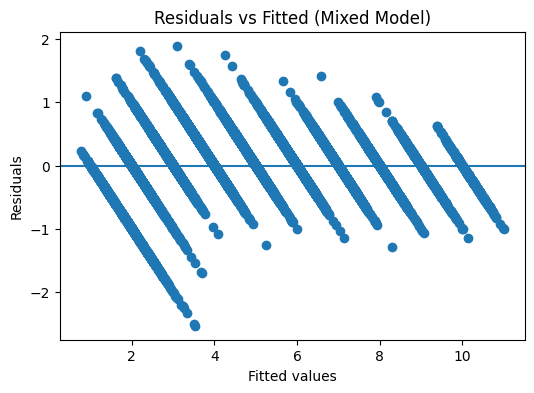

In [372]:
# Residuals vs Fitted (Linearity + Homoscedasticity)

import matplotlib.pyplot as plt

fitted = model3_mixed.fittedvalues
residuals = model3_mixed.resid

plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Mixed Model)")
plt.show()

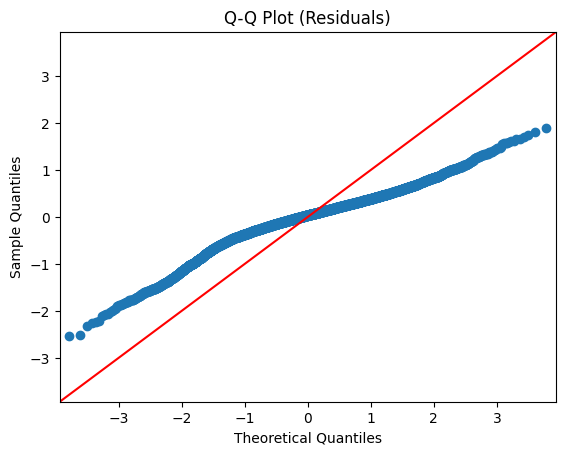

In [373]:
# Normality of Residuals (Q-Q Plot)

import statsmodels.api as sm

sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot (Residuals)")
plt.show()

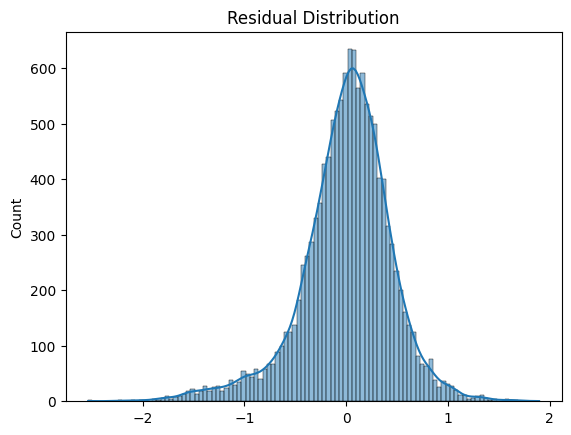

In [374]:
# Histogram of Residuals

import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

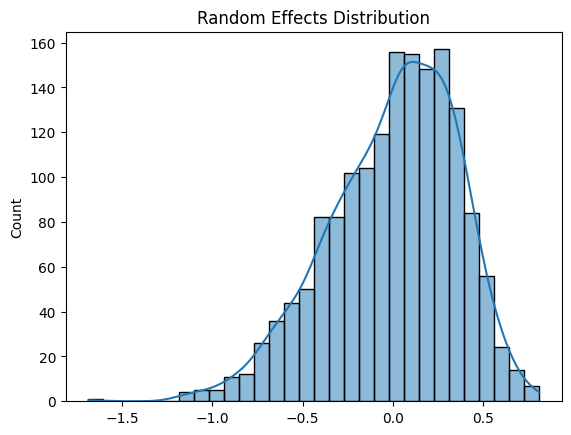

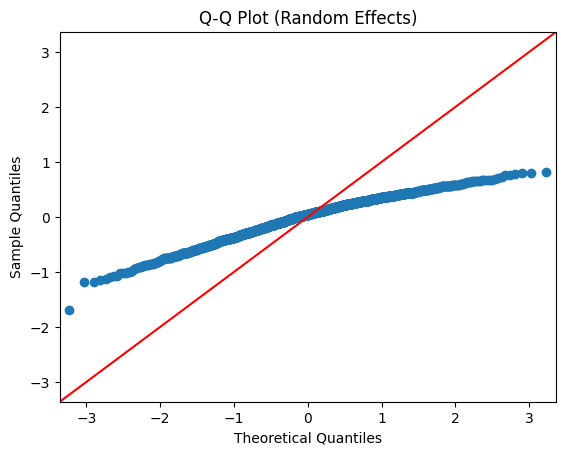

In [375]:
# Normality of Random Effects (VERY IMPORTANT)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Random intercepts
random_effects = model3_mixed.random_effects

# Extract values safely
re_values = np.array([v.values[0] for v in random_effects.values()])

# Histogram
sns.histplot(re_values, kde=True)
plt.title("Random Effects Distribution")
plt.show()

# Q-Q Plot
sm.qqplot(re_values, line='45')
plt.title("Q-Q Plot (Random Effects)")
plt.show()

In [376]:
import statsmodels.stats.api as sms

bp_test = sms.het_breuschpagan(model3_mixed.resid, model3_mixed.model.exog)

labels = ["LM Statistic", "LM-Test p-value", "F-Statistic", "F-Test p-value"]
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(2943.0583455206074), 'LM-Test p-value': np.float64(0.0), 'F-Statistic': np.float64(135.94855590248432), 'F-Test p-value': np.float64(0.0)}


In [377]:
# t-statistics
t_values = model3_mixed.tvalues

# p-values
p_values = model3_mixed.pvalues

# coefficients
coefficients = model3_mixed.params

print("T-values:\n", t_values)
print("\nP-values:\n", p_values)

T-values:
 Intercept                     39.593195
cycle_phase_Luteal            -1.460065
cycle_phase_Menstrual         -0.626609
pms_symptoms_Yes              -1.735967
ovulation_result_Positive      0.791369
flow_level                    29.563853
mood_score                   -15.107661
stress_score_cycle           -53.794756
sleep_hours_cycle             17.040173
energy_level                 -16.291349
concentration_score          -19.680848
estrogen_pgml                 -0.026658
progesterone_ngml              1.206293
overall_health_score        -164.906134
log_consistency_score          0.205647
prepared_before_period         0.469984
age                            1.211216
bmi                          -16.092600
diet_quality                  -0.366931
exercise_frequency            -1.604620
sleep_hours                   12.115446
caffeine_intake                0.818447
water_intake_liters            0.546467
alcohol_consumption            0.383401
smoking_status               

In [378]:
alpha = 0.05

non_significant = p_values[p_values > alpha]
print("\nNon-significant variables:\n", non_significant)


Non-significant variables:
 cycle_phase_Luteal           0.144272
cycle_phase_Menstrual        0.530916
pms_symptoms_Yes             0.082570
ovulation_result_Positive    0.428729
estrogen_pgml                0.978733
progesterone_ngml            0.227705
log_consistency_score        0.837067
prepared_before_period       0.638366
age                          0.225813
diet_quality                 0.713671
exercise_frequency           0.108577
caffeine_intake              0.413102
water_intake_liters          0.584745
alcohol_consumption          0.701423
smoking_status               0.733539
birth_control_use            0.637140
stress_score_baseline        0.497595
cycle_number                 0.344774
dtype: float64


In [379]:
significant = p_values[p_values <= alpha]
print("\nSignificant variables:\n", significant)


Significant variables:
 Intercept                0.000000e+00
flow_level              4.358574e-192
mood_score               1.441671e-51
stress_score_cycle       0.000000e+00
sleep_hours_cycle        4.135076e-65
energy_level             1.136930e-59
concentration_score      3.146955e-86
overall_health_score     0.000000e+00
bmi                      2.875051e-58
sleep_hours              8.748645e-34
pcos_diagnosed           8.206244e-43
Group Var                1.139429e-98
dtype: float64


TESTING FOR COMPARIANG BEST MODEL

In [380]:
model1 = model1_mixed.model
result1 = model1.fit(reml=False)

model2 = model2_mixed.model
result2 = model2.fit(reml=False)

model3 = model3_mixed.model
result3 = model3.fit(reml=False)

model4 = model4_mixed.model
result4 = model4.fit(reml=False)

In [381]:
# Likelihood Ratio Test (BEST alternative)

from scipy.stats import chi2

def lr_test(model_full, model_reduced, name=""):
    lr_stat = 2 * (model_full.llf - model_reduced.llf)
    df_diff = model_full.df_modelwc - model_reduced.df_modelwc
    p_value = chi2.sf(lr_stat, df_diff)

    print(f"\nComparing Full vs {name}")
    print("LR stat:", lr_stat)
    print("df difference:", df_diff)
    print("p-value:", p_value)

In [382]:
lr_test(result4, result3, "Model 3")
lr_test(result4, result2, "Model 2")
lr_test(result4, result1, "Model 1")


Comparing Full vs Model 3
LR stat: -827.5371489808022
df difference: 4
p-value: 1.0

Comparing Full vs Model 2
LR stat: 1329.9615481028595
df difference: 13
p-value: 1.8721958003874466e-276

Comparing Full vs Model 1
LR stat: 26908.379805259785
df difference: 20
p-value: 0.0


LR statistic can NEVER be negative
Formula is:
LR=2(LL_full-LL_reduced)

So negative means:

❗ Your “full model” is actually worse than the reduced model

Model 4 does NOT improve over Model 3
In fact, Model 3 is better

✔ So:
👉 Model 3 preferred over Model 4

Model 4 is significantly better than Model 2 ✔

Model 4 is MUCH better than Model 1 ✔

In [384]:
params_sorted = model3_mixed.params.sort_values()

print(params_sorted)

overall_health_score         -1.914103
stress_score_cycle           -0.372149
concentration_score          -0.086616
energy_level                 -0.059365
mood_score                   -0.056904
cycle_phase_Luteal           -0.028736
smoking_status               -0.020067
pms_symptoms_Yes             -0.017217
exercise_frequency           -0.016714
cycle_length_days            -0.008085
cycle_phase_Menstrual        -0.005900
diet_quality                 -0.003793
alcohol_consumption          -0.002855
estrogen_pgml                -0.000024
progesterone_ngml             0.003392
caffeine_intake               0.004628
stress_score_baseline         0.005110
prepared_before_period        0.005616
ovulation_result_Positive     0.019077
sleep_hours                   0.136422
sleep_hours_cycle             0.201994
work_hours_lost               0.250195
flow_level                    0.291850
Group Var                     0.776422
log_consistency_score         0.888054
Intercept                

Wald Test (for individual coefficients)

H0: βi = 0   vs   H1: βi != 0

In [386]:
# Wald Test

summary_table = pd.DataFrame({
    "Coefficient": model3_mixed.params,
    "p-value": model3_mixed.pvalues
})

summary_table = summary_table.sort_values(by="Coefficient")

print(summary_table)

                           Coefficient        p-value
overall_health_score         -1.914103   0.000000e+00
stress_score_cycle           -0.372149   0.000000e+00
concentration_score          -0.086616   7.475826e-80
energy_level                 -0.059365   1.450795e-55
mood_score                   -0.056904   9.305554e-51
cycle_phase_Luteal           -0.028736   1.266447e-01
smoking_status               -0.020067   5.768747e-01
pms_symptoms_Yes             -0.017217   7.041191e-02
exercise_frequency           -0.016714   2.761025e-01
cycle_length_days            -0.008085   9.251481e-05
cycle_phase_Menstrual        -0.005900   7.425745e-01
diet_quality                 -0.003793   7.835862e-01
alcohol_consumption          -0.002855   8.624695e-01
estrogen_pgml                -0.000024   9.055394e-01
progesterone_ngml             0.003392   1.669656e-01
caffeine_intake               0.004628   6.522199e-01
stress_score_baseline         0.005110   5.500770e-01
prepared_before_period      

In [387]:
# significant variables (p < 0.05)
significant_vars = summary_table[summary_table["p-value"] < 0.05]

print(significant_vars.sort_values(by="Coefficient"))

                      Coefficient        p-value
overall_health_score    -1.914103   0.000000e+00
stress_score_cycle      -0.372149   0.000000e+00
concentration_score     -0.086616   7.475826e-80
energy_level            -0.059365   1.450795e-55
mood_score              -0.056904   9.305554e-51
cycle_length_days       -0.008085   9.251481e-05
sleep_hours              0.136422   9.234404e-31
sleep_hours_cycle        0.201994  6.834065e-132
work_hours_lost          0.250195  9.697544e-290
flow_level               0.291850  4.394691e-196
Group Var                0.776422   5.698437e-94
Intercept               20.741558   0.000000e+00


In [388]:
# Non-significant variables (p > 0.05)
non_significant = summary_table[summary_table["p-value"] > 0.05]

print(non_significant.sort_values(by="p-value"))

                           Coefficient   p-value
ovulation_result_Positive     0.019077  0.053979
pms_symptoms_Yes             -0.017217  0.070412
log_consistency_score         0.888054  0.104530
cycle_phase_Luteal           -0.028736  0.126645
progesterone_ngml             0.003392  0.166966
exercise_frequency           -0.016714  0.276103
prepared_before_period        0.005616  0.549384
stress_score_baseline         0.005110  0.550077
smoking_status               -0.020067  0.576875
caffeine_intake               0.004628  0.652220
cycle_phase_Menstrual        -0.005900  0.742575
diet_quality                 -0.003793  0.783586
alcohol_consumption          -0.002855  0.862469
estrogen_pgml                -0.000024  0.905539


In [383]:
import statsmodels.api as sm

anova_table = sm.stats.anova_lm(model1, typ=2)
print(anova_table)

AttributeError: 'MixedLM' object has no attribute 'model'

In [ ]:
# F-statistic
print("F-statistic:", model1.fvalue)

# p-value of F-test
print("F-test p-value:", model1.f_pvalue)

T test

In [ ]:
# t-statistics
t_values = model1.tvalues

# p-values
p_values = model1.pvalues

# coefficients
coefficients = model1.params

print("T-values:\n", t_values)
print("\nP-values:\n", p_values)

In [ ]:
alpha = 0.05

non_significant = p_values[p_values > alpha]
print("\nNon-significant variables:\n", non_significant)

In [ ]:
significant = p_values[p_values <= alpha]
print("\nSignificant variables:\n", significant)

ANOVA


In [ ]:
import statsmodels.api as sm

anova_table = sm.stats.anova_lm(model1, typ=2)
print(anova_table)

F test

In [ ]:
# F-statistic
print("F-statistic:", model1.fvalue)

# p-value of F-test
print("F-test p-value:", model1.f_pvalue)